# Interacting with a calculator through an adapter

This notebook focusses on how users interact with adapters in Ubermag. It comments on internal implementation details and primarily targets authors of adapter packages.

In [1]:
# !rm -rf sample

In [2]:
import discretisedfield as df
import micromagneticmodel as mm

import mock_adapter

The user first creates a simulation object. The name must be a valid Python variable name. The energy and dynamics equation can (but don't have to) be defined by combining terms from micromagneticmodel. The initial magnetisation is defined as `system.m`. For finite-difference simulations this typically should be an instance of `discretisedfield.Field` but no checks are performed, so the adapter package is free to pick a suitable datatype for magnetisation.

In [3]:
system = mm.System(name="sample")
# field in z direction
system.energy = mm.Zeeman(H=[0, 0, 4])
# initial magnetisation in x direction
system.m = df.Field(
    df.Mesh(p1=(0, 0, 0), p2=(1, 1, 1), n=(2, 2, 2)), nvdim=3, value=(1, 0, 0), norm=1e6
)

The user next creates an instance of a `Driver` from the adapter package.

Energy minimisation can be done with a `MinDriver`.

In [4]:
md = mock_adapter.MinDriver()

The driver instance can now be used to run simulations, either using `drive` or `schedule`.

`drive` runs a simulation synchronously and updates the system at the end.

In [5]:
md.drive(system)

Running Ubermag Mock Calculator (MockCalculatorRunner)[2026-06-12T17:09:18]... (1.9 s)


In [6]:
system.m.orientation.mean()  # final magnetisation in z direction, along the field

array([0., 0., 1.])

Between simulations the energy and dynamics equation can be updated.

In [7]:
system.energy.zeeman.H = [0, 1, 0]  # change field direction to y

`schedule` writes inputs for a simulation and submits it to a scheduling system but does not update the system object. The user needs to pass the scheduling command (e.g. `sbatch` for slurm) and a header for the scheduling script to request resources (e.g. for slurm `#SBATCH ...` lines, either as string or file on disk).

In [8]:
md.schedule(
    system, "python", "# no header"
)  # no scheduling system available for testing -> fake scheduling by using python as command and only having comments in the job script `job.sh`

Running 'python job.sh' in '/home/mlang/repos/ubermag-devtools/repos/ubermagcalculatorbase/docs/sample/drive-1'.


In [9]:
system.m.orientation.mean()  # the magnetisation has not changed

array([0., 0., 1.])

Time integration can be done with a `TimeDriver`.

In [10]:
td = mock_adapter.TimeDriver()

We need to set a dynamics equation for the time evolution. `mock_adapter` only requires a damping term.

In [11]:
system.dynamics = mm.Damping(alpha=0.5)

In [12]:
td.drive(system, t=0.5e-9, n=5)  # simulate 0.5 ns and save 5 steps

Running Ubermag Mock Calculator (MockCalculatorRunner)[2026-06-12T17:09:29]... (2.0 s)


In [13]:
system.m.orientation.mean()  # the magnetisation has started to rotate in the y direction

array([ 1.66533454e-16,  1.94093447e-01, -9.80983045e-01])

The `table` attribute contains tabular data of the run.

In [14]:
system.table.data

,t,energy,mx,my,mz,alpha_factor,precession_angle
0,1.000000e-10,-1.000000e-10,5.873323e-01,0.039252,0.808394,0.975005,0.628319
1,2.000000e-10,-2.000000e-10,9.481296e-01,0.078394,0.308066,0.950042,0.628319
2,3.000000e-10,-3.000000e-10,9.444888e-01,0.117319,-0.306883,0.925140,0.628319
3,4.000000e-10,-4.000000e-10,5.805965e-01,0.155919,-0.799123,0.900332,0.628319
4,5.000000e-10,-5.000000e-10,1.665335e-16,0.194093,-0.980983,0.875647,0.628319


In [15]:
td.drive(system, t=10e-9, n=100)  # simulate another 10 ns and save 100 steps

Running Ubermag Mock Calculator (MockCalculatorRunner)[2026-06-12T17:09:37]... (2.6 s)


In [16]:
system.m.orientation.mean()  # the magnetisation now points predominantly in the y direction

array([ 6.76542156e-17,  9.99830512e-01, -1.84104986e-02])

The `table` attribute can be used to plot the time evolution of the system.

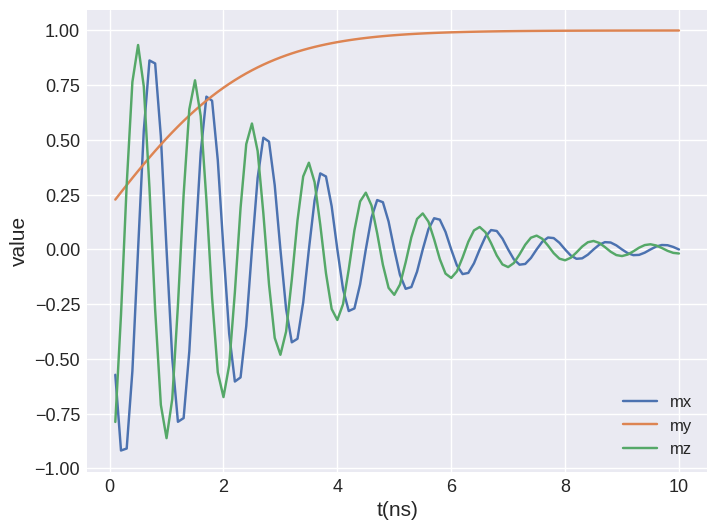

In [17]:
system.table.mpl(y=["mx", "my", "mz"])

Users can later use `micromagneticdata` to read simulation output. This will make use of two plugins that each calculator needs to implement.

In [1]:
import micromagneticdata as mdata

In [2]:
data = mdata.Data(name="sample")  # access the top-level simulation directory

In [3]:
data.info

,drive_number,date,time,start_time,adapter,adapter_version,driver,end_time,elapsed_time,success,info.json,t,n
0,0,2026-06-12,17:09:18,2026-06-12T17:09:18,mock_adapter,0.1.0,MinDriver,2026-06-12T17:09:20,00:00:02,True,available,<NA>,<NA>
1,1,2026-06-12,17:09:25,2026-06-12T17:09:25,mock_adapter,0.1.0,MinDriver,<NA>,<NA>,<NA>,available,<NA>,<NA>
2,2,2026-06-12,17:09:29,2026-06-12T17:09:29,mock_adapter,0.1.0,TimeDriver,2026-06-12T17:09:31,00:00:03,True,available,0.0,5
3,3,2026-06-12,17:09:37,2026-06-12T17:09:37,mock_adapter,0.1.0,TimeDriver,2026-06-12T17:09:39,00:00:03,True,available,0.0,100


In [4]:
data[0]  # initial energy minimisation

MockCalculatorDrive(name='sample', number=0, dirname='/home/mlang/repos/ubermag-devtools/repos/ubermagcalculatorbase/docs', x='iteration')

In [12]:
print(data[0].calculator_script)  # input script for mock_calculator

{
    "H": [
        0.0,
        0.0,
        4.0
    ],
    "mode": "min",
    "save_steps": false
}


In [5]:
drive = data[-1]  # second time drive

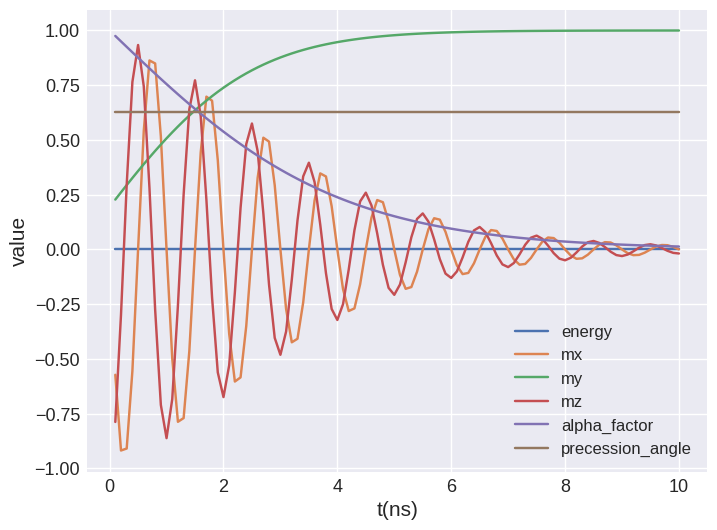

In [15]:
drive.table.mpl()

In [21]:
drive.register_callback(lambda f: f.orientation).hv(
    kdims=["x", "y"], scalar_kw=dict(clim=(-1, 1), cmap="coolwarm")
)

:DynamicMap   [z,t]
   :Overlay
      .Image.I       :Image   [x,y]   (field)
      .VectorField.I :VectorField   [x,y]   (angle,mag)

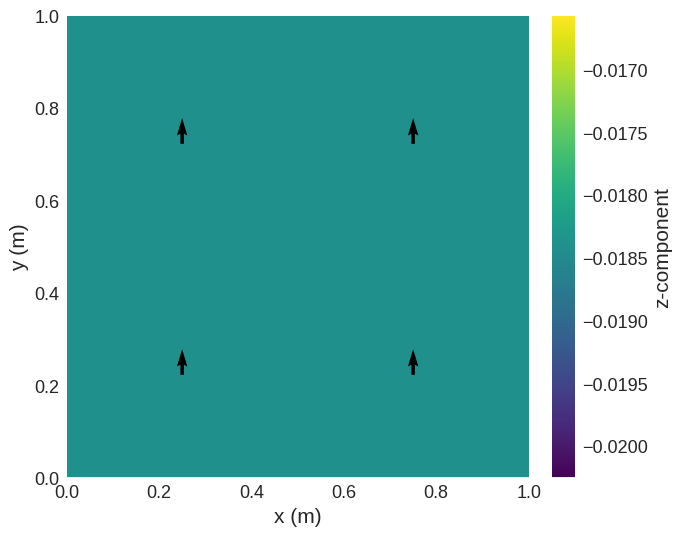

In [20]:
drive[-1].sel("z").orientation.mpl()